In [1]:
!pip uninstall -y transformers datasets huggingface_hub accelerate tokenizers

!pip install -U \
transformers==4.41.2 \
datasets==2.19.1 \
huggingface_hub==0.23.2 \
accelerate==0.30.1 \
tokenizers==0.19.1

Found existing installation: transformers 5.0.0
Uninstalling transformers-5.0.0:
  Successfully uninstalled transformers-5.0.0
Found existing installation: datasets 4.0.0
Uninstalling datasets-4.0.0:
  Successfully uninstalled datasets-4.0.0
Found existing installation: huggingface_hub 1.11.0
Uninstalling huggingface_hub-1.11.0:
  Successfully uninstalled huggingface_hub-1.11.0
Found existing installation: accelerate 1.13.0
Uninstalling accelerate-1.13.0:
  Successfully uninstalled accelerate-1.13.0
Found existing installation: tokenizers 0.22.2
Uninstalling tokenizers-0.22.2:
  Successfully uninstalled tokenizers-0.22.2
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 43.8/43.8 kB 4.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.1/9.1 MB 85.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 542.0/542.0 kB 46.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 401.7/401.7 kB 26.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 302.6/30

In [2]:
# Check GPU availability
import torch
print(f"GPU Available: {torch.cuda.is_available()}")
print(f"GPU Device: {torch.cuda.get_device_name(0) if torch.cuda.is_available() else 'No GPU'}")
print(f"GPU Count: {torch.cuda.device_count()}")

if torch.cuda.is_available():
    print(f"CUDA Version: {torch.version.cuda}")
    print(f"GPU Memory: {torch.cuda.get_device_properties(0).total_memory / 1e9:.2f} GB")

GPU Available: True
GPU Device: Tesla T4
GPU Count: 1
CUDA Version: 12.8
GPU Memory: 15.64 GB


In [3]:
!pip uninstall -y peft

Found existing installation: peft 0.19.1
Uninstalling peft-0.19.1:
  Successfully uninstalled peft-0.19.1


In [4]:
# Import all required libraries
import pandas as pd
import numpy as np
from datetime import datetime
import warnings
warnings.filterwarnings('ignore')

# ML libraries
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, classification_report, roc_auc_score
)

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns
sns.set_style('whitegrid')

# PyTorch
import torch
from torch.utils.data import Dataset, DataLoader
from transformers import (
    AutoTokenizer, AutoModelForSequenceClassification,
    Trainer, TrainingArguments, EarlyStoppingCallback
)
import pickle
import re
import json

print("All libraries imported successfully")

All libraries imported successfully


In [5]:
def clean_text(text: str, keep_emojis: bool = False) -> str:
    """
    Clean and preprocess text for hate speech detection.
    """
    if not isinstance(text, str):
        return ""

    # Remove URLs
    text = re.sub(r'http\S+|www\S+|https\S+', '', text, flags=re.MULTILINE)

    # Remove mentions (@user)
    text = re.sub(r'@\w+', '', text)

    # Remove hashtags but keep the word
    text = re.sub(r'#(\w+)', r'\1', text)

    # Remove special characters
    text = re.sub(r'[^a-zA-Z0-9\s\u0900-\u097F]', '', text)

    # Convert to lowercase
    text = text.lower()

    # Handle extra whitespace
    text = re.sub(r'\s+', ' ', text).strip()

    return text


def merge_external_datasets_in_colab(combined_path: str, indo_path: str, output_path: str = '/content/merged_hate_speech_training.csv'):
    """Merge the two external hate-speech datasets into one binary CSV."""
    combined_df = pd.read_csv(combined_path).copy()
    indo_df = pd.read_csv(indo_path).copy()

    combined_df = combined_df[['text', 'hate_label']].dropna().rename(
        columns={'hate_label': 'label'}
    )
    combined_df['label'] = combined_df['label'].astype(int)
    combined_df['source_dataset'] = 'combined_hate_speech_dataset_2'

    indo_df = indo_df[['Comment', 'Label']].dropna(subset=['Comment', 'Label']).rename(
        columns={'Comment': 'text'}
    )
    indo_df['Label'] = indo_df['Label'].astype(str).str.strip().str.strip("'").str.upper()
    indo_df = indo_df[indo_df['Label'].isin(['HS0', 'HS1', 'HSN'])].copy()
    indo_df['label'] = indo_df['Label'].map({'HS0': 0, 'HS1': 1, 'HSN': 1})
    indo_df['source_dataset'] = 'indo_hatespeech_dataset'
    indo_df = indo_df[['text', 'label', 'source_dataset']]

    merged_df = pd.concat([
        combined_df[['text', 'label', 'source_dataset']],
        indo_df,
    ], ignore_index=True)
    merged_df['text'] = merged_df['text'].astype(str).str.strip()
    merged_df = merged_df[merged_df['text'] != ''].copy()

    # Deduplicate across both datasets after basic text normalization.
    merged_df['text_key'] = (
        merged_df['text'].str.lower().str.replace(r'\s+', ' ', regex=True).str.strip()
    )
    merged_df = merged_df.drop_duplicates(subset='text_key', keep='first').drop(columns=['text_key'])
    merged_df.to_csv(output_path, index=False)

    print(f'Merged dataset saved to: {output_path}')
    print(f'  - Total samples: {len(merged_df)}')
    print(f"  - Label distribution:\n{merged_df['label'].value_counts().to_string()}\n")
    return output_path


def load_and_preprocess_data(csv_path: str, text_column: str = 'text', label_column: str = 'label'):
    """
    Load CSV and preprocess into train/test splits.
    """
    print("\n" + "="*80)
    print("STEP 1: LOADING AND PREPROCESSING DATA")
    print("="*80 + "\n")

    # Load dataset
    print(f"Loading dataset from: {csv_path}")
    df = pd.read_csv(csv_path)
    print(f"  - Loaded {len(df)} samples")
    print(f"  - Columns: {list(df.columns)}")
    print(f"  - Label distribution:\n{df[label_column].value_counts().to_string()}\n")

    # Clean text
    print("Cleaning text data...")
    X_clean = np.array([clean_text(str(text)) for text in df[text_column].values])
    y = df[label_column].values

    # Split data (80/20)
    print(f"Splitting data (80/20)...")
    X_train, X_test, y_train, y_test = train_test_split(
        X_clean, y, test_size=0.2, random_state=42, stratify=y
    )

    print(f"  - Training samples: {len(X_train)}")
    print(f"  - Test samples: {len(X_test)}")
    print(f"\n  Sample cleaned text: {X_train[0][:100]}...\n")

    return X_train, X_test, y_train, y_test

print("Text preprocessing functions defined")

Text preprocessing functions defined


In [6]:
# First, let's check what's available in Colab or Drive
import os

dataset_path = None
merged_output_path = '/content/merged_hate_speech_training.csv'

possible_paths = [
    merged_output_path,
    '/content/merged_hate_speech_training.csv',
    '/content/drive/MyDrive/merged_hate_speech_training.csv',
    '/content/combined_hate_speech_dataset.csv'
]

print("Looking for dataset...\n")

for path in possible_paths:
    if os.path.exists(path):
        dataset_path = path
        print(f"Found dataset at: {dataset_path}")
        break

if dataset_path is None:
    combined_source = '/content/combined_hate_speech_dataset 2.csv'
    indo_source = '/content/Indo-HateSpeech_Dataset.csv'

    if os.path.exists(combined_source) and os.path.exists(indo_source):
        print('Merged dataset not found. Building it from the two uploaded source CSVs...')
        dataset_path = merge_external_datasets_in_colab(combined_source, indo_source, merged_output_path)
    else:
        print('Dataset not found in common locations.')
        print('\nUpload one of these options:')
        print('1. merged_hate_speech_training.csv')
        print('2. both source files: combined_hate_speech_dataset 2.csv and Indo-HateSpeech_Dataset.csv')
        dataset_path = merged_output_path
        print(f'Expected merged dataset path: {dataset_path}')

Looking for dataset...

Found dataset at: /content/combined_hate_speech_dataset.csv


In [7]:
# Verify dataset exists and load it
if not os.path.exists(dataset_path):
    raise FileNotFoundError(f"Dataset not found at: {dataset_path}")

# Load and preprocess data
X_train, X_test, y_train, y_test = load_and_preprocess_data(
    dataset_path,
    text_column='text',
    label_column='label'
)


STEP 1: LOADING AND PREPROCESSING DATA

Loading dataset from: /content/combined_hate_speech_dataset.csv
  - Loaded 29550 samples
  - Columns: ['text', 'hate_label', 'source', 'profanity_score', 'language', 'dataset_version', 'combined_date', 'text_length', 'word_count']
  - Label distribution:
hate_label
0    15825
1    13725

Cleaning text data...
Splitting data (80/20)...
  - Training samples: 23640
  - Test samples: 5910

  Sample cleaned text: भक्तो तुम्हारी अम्मा यसोदा मैया भी पहुंच गई पैसे लेने लेकिन तुम्हारे पप्पा...



In [8]:
def train_baseline_model(X_train, y_train, X_test, y_test):
    """
    Train baseline model using TF-IDF + Logistic Regression.
    """
    print("\n" + "="*80)
    print("STEP 2: TRAINING BASELINE MODEL (TF-IDF + LOGISTIC REGRESSION)")
    print("="*80 + "\n")

    # Initialize TF-IDF Vectorizer
    print("Initializing TF-IDF Vectorizer...")
    vectorizer = TfidfVectorizer(
        max_features=5000,
        ngram_range=(1, 2),
        lowercase=True,
        stop_words='english',
        min_df=2,
        max_df=0.8
    )

    # Fit vectorizer and transform training data
    print("Fitting TF-IDF Vectorizer on training data...")
    X_train_tfidf = vectorizer.fit_transform(X_train)
    print(f"  - Vocabulary size: {len(vectorizer.vocabulary_)}")
    print(f"  - Training data shape: {X_train_tfidf.shape}")
    print(f"  - Sparsity: {1.0 - X_train_tfidf.nnz / (X_train_tfidf.shape[0] * X_train_tfidf.shape[1]):.2%}\n")

    # Train Logistic Regression
    print("Training Logistic Regression...")
    model = LogisticRegression(
        max_iter=1000,
        random_state=42,
        solver='lbfgs',
        class_weight='balanced'
    )
    model.fit(X_train_tfidf, y_train)
    print(f"  ✓ Model trained successfully\n")

    # Evaluate
    print("Evaluating on test data...")
    X_test_tfidf = vectorizer.transform(X_test)
    y_pred = model.predict(X_test_tfidf)
    y_pred_proba = model.predict_proba(X_test_tfidf)[:, 1]

    accuracy = accuracy_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred, zero_division=0)
    recall = recall_score(y_test, y_pred, zero_division=0)
    f1 = f1_score(y_test, y_pred, zero_division=0)
    roc_auc = roc_auc_score(y_test, y_pred_proba)

    print(f"  Accuracy:  {accuracy:.4f}")
    print(f"  Precision: {precision:.4f}")
    print(f"  Recall:    {recall:.4f}")
    print(f"  F1 Score:  {f1:.4f}")
    print(f"  ROC-AUC:   {roc_auc:.4f}\n")

    # Confusion matrix
    cm = confusion_matrix(y_test, y_pred)
    print(f"Confusion Matrix:")
    print(f"  TN={cm[0,0]}, FP={cm[0,1]}, FN={cm[1,0]}, TP={cm[1,1]}\n")

    metrics = {
        'accuracy': accuracy,
        'precision': precision,
        'recall': recall,
        'f1': f1,
        'roc_auc': roc_auc,
        'confusion_matrix': cm,
        'y_pred': y_pred
    }

    return model, vectorizer, metrics

# Train baseline
baseline_model, baseline_vectorizer, baseline_metrics = train_baseline_model(
    X_train, y_train, X_test, y_test
)


STEP 2: TRAINING BASELINE MODEL (TF-IDF + LOGISTIC REGRESSION)

Initializing TF-IDF Vectorizer...
Fitting TF-IDF Vectorizer on training data...
  - Vocabulary size: 5000
  - Training data shape: (23640, 5000)
  - Sparsity: 99.79%

Training Logistic Regression...
  ✓ Model trained successfully

Evaluating on test data...
  Accuracy:  0.6924
  Precision: 0.6654
  Recall:    0.6794
  F1 Score:  0.6723
  ROC-AUC:   0.7613

Confusion Matrix:
  TN=2227, FP=938, FN=880, TP=1865



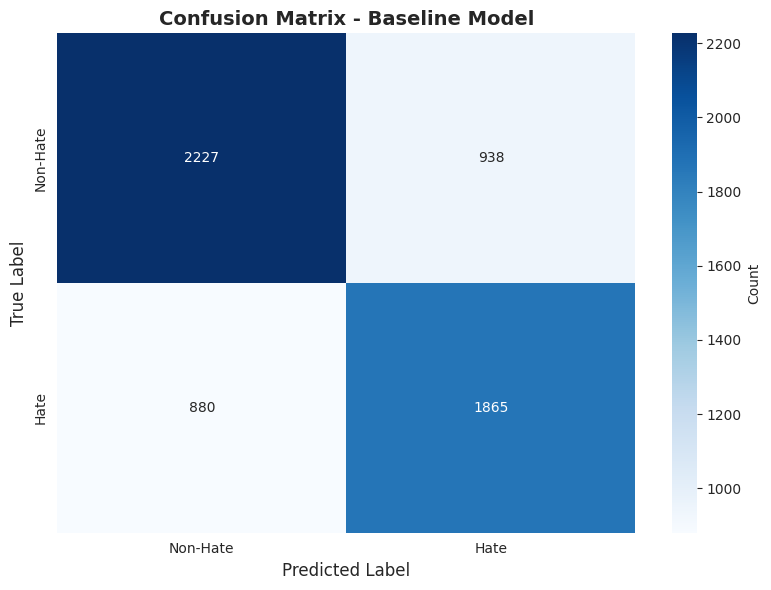

Confusion matrix saved


In [9]:
# Plot confusion matrix for baseline
plt.figure(figsize=(8, 6))
sns.heatmap(baseline_metrics['confusion_matrix'], annot=True, fmt='d', cmap='Blues',
            xticklabels=['Non-Hate', 'Hate'],
            yticklabels=['Non-Hate', 'Hate'],
            cbar_kws={'label': 'Count'})
plt.title('Confusion Matrix - Baseline Model', fontsize=14, fontweight='bold')
plt.ylabel('True Label', fontsize=12)
plt.xlabel('Predicted Label', fontsize=12)
plt.tight_layout()
plt.savefig('/content/confusion_matrix_baseline.png', dpi=100, bbox_inches='tight')
plt.show()
print("Confusion matrix saved")

In [10]:
class HateSpeechDataset(Dataset):
    """PyTorch Dataset for hate speech detection."""

    def __init__(self, texts, labels, tokenizer, max_length=128):
        self.texts = texts
        self.labels = labels
        self.tokenizer = tokenizer
        self.max_length = max_length

    def __len__(self):
        return len(self.texts)

    def __getitem__(self, idx):
        text = str(self.texts[idx])
        label = int(self.labels[idx])

        encoding = self.tokenizer(
            text,
            add_special_tokens=True,
            max_length=self.max_length,
            padding='max_length',
            truncation=True,
            return_tensors='pt'
        )

        return {
            'input_ids': encoding['input_ids'].squeeze(0),
            'attention_mask': encoding['attention_mask'].squeeze(0),
            'labels': torch.tensor(label, dtype=torch.long)
        }


def compute_metrics(p):
    """Compute metrics for Trainer."""
    predictions, labels = p
    predictions = np.argmax(predictions, axis=1)

    accuracy = accuracy_score(labels, predictions)
    precision = precision_score(labels, predictions, zero_division=0)
    recall = recall_score(labels, predictions, zero_division=0)
    f1 = f1_score(labels, predictions, zero_division=0)

    return {
        'accuracy': accuracy,
        'precision': precision,
        'recall': recall,
        'f1': f1
    }

print("Dataset class and compute_metrics function defined")

Dataset class and compute_metrics function defined


In [11]:
print("\n" + "="*80)
print("STEP 3: TRAINING TRANSFORMER MODEL (XLM-RoBERTa)")
print("="*80 + "\n")

# Load tokenizer and model
print("Loading XLM-RoBERTa model and tokenizer...")
model_name = 'xlm-roberta-base'
tokenizer = AutoTokenizer.from_pretrained(model_name)
model = AutoModelForSequenceClassification.from_pretrained(model_name, num_labels=2)
print(f"  Model loaded (vocab size: {len(tokenizer)})\n")

# Create datasets
print("Creating PyTorch datasets...")
train_dataset = HateSpeechDataset(X_train, y_train, tokenizer, max_length=128)
test_dataset = HateSpeechDataset(X_test, y_test, tokenizer, max_length=128)
print(f"  - Train dataset size: {len(train_dataset)}")
print(f"  - Test dataset size: {len(test_dataset)}\n")

# Training arguments
print("Setting up training arguments...")
training_args = TrainingArguments(
    output_dir='/content/transformer_model',
    num_train_epochs=2,
    per_device_train_batch_size=8,
    per_device_eval_batch_size=8,
    warmup_steps=100,
    weight_decay=0.01,
    logging_steps=50,
    logging_dir='/content/logs',
    learning_rate=2e-5,
    save_total_limit=2,
    load_best_model_at_end=True,
    metric_for_best_model='f1',
    save_strategy='steps',
    save_steps=100,
    eval_strategy='steps',
    eval_steps=100,
    seed=42,
    report_to=[]
)
print(f"  - Epochs: {training_args.num_train_epochs}")
print(f"  - Batch size: {training_args.per_device_train_batch_size}")
print(f"  - Learning rate: {training_args.learning_rate}\n")

# Create Trainer
print("Creating Trainer...")
trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=train_dataset,
    eval_dataset=test_dataset,
    compute_metrics=compute_metrics,
    callbacks=[EarlyStoppingCallback(early_stopping_patience=3)]
)
print(f"  Trainer created\n")

# Train
print("Starting training... (this may take 30-60 minutes)")
print("="*80)
train_result = trainer.train()
print("\n" + "="*80)
print(f"Training completed!")
print(f"Training loss: {train_result.training_loss:.4f}\n")


STEP 3: TRAINING TRANSFORMER MODEL (XLM-RoBERTa)

Loading XLM-RoBERTa model and tokenizer...


tokenizer_config.json:   0%|          | 0.00/25.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/615 [00:00<?, ?B/s]

sentencepiece.bpe.model:   0%|          | 0.00/5.07M [00:00<?, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

model.safetensors:   0%|          | 0.00/1.12G [00:00<?, ?B/s]

Some weights of XLMRobertaForSequenceClassification were not initialized from the model checkpoint at xlm-roberta-base and are newly initialized: ['classifier.dense.bias', 'classifier.dense.weight', 'classifier.out_proj.bias', 'classifier.out_proj.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


  Model loaded (vocab size: 250002)

Creating PyTorch datasets...
  - Train dataset size: 23640
  - Test dataset size: 5910

Setting up training arguments...
  - Epochs: 2
  - Batch size: 8
  - Learning rate: 2e-05

Creating Trainer...
  Trainer created

Starting training... (this may take 30-60 minutes)


Step,Training Loss,Validation Loss,Accuracy,Precision,Recall,F1
100,0.689500,0.667075,0.624196,0.644273,0.426230,0.513045
200,0.708100,0.682268,0.552623,0.775956,0.051730,0.096995
300,0.703600,0.687599,0.536548,0.875000,0.002550,0.005085
400,0.662700,0.675447,0.662775,0.652350,0.586521,0.617687
500,0.672800,0.629759,0.639425,0.593313,0.711111,0.646893
600,0.656300,0.624991,0.674450,0.667074,0.597086,0.630142
700,0.659200,0.582352,0.667851,0.722159,0.463024,0.564262
800,0.603800,0.637857,0.681387,0.683560,0.584699,0.630277



Training completed!
Training loss: 0.6648



In [12]:
# Evaluate transformer
print("\n" + "="*80)
print("STEP 4: EVALUATING TRANSFORMER MODEL")
print("="*80 + "\n")

eval_results = trainer.evaluate()
print(f"Evaluation Results:")
print(f"  Accuracy:  {eval_results['eval_accuracy']:.4f}")
print(f"  Precision: {eval_results['eval_precision']:.4f}")
print(f"  Recall:    {eval_results['eval_recall']:.4f}")
print(f"  F1 Score:  {eval_results['eval_f1']:.4f}\n")

# Get predictions for confusion matrix
predictions = trainer.predict(test_dataset)
y_pred_transformer = np.argmax(predictions.predictions, axis=1)
cm_transformer = confusion_matrix(y_test, y_pred_transformer)

print(f"Confusion Matrix:")
print(f"  TN={cm_transformer[0,0]}, FP={cm_transformer[0,1]}, FN={cm_transformer[1,0]}, TP={cm_transformer[1,1]}\n")

transformer_metrics = {
    'accuracy': eval_results['eval_accuracy'],
    'precision': eval_results['eval_precision'],
    'recall': eval_results['eval_recall'],
    'f1': eval_results['eval_f1'],
    'confusion_matrix': cm_transformer,
    'y_pred': y_pred_transformer
}


STEP 4: EVALUATING TRANSFORMER MODEL



Evaluation Results:
  Accuracy:  0.6394
  Precision: 0.5933
  Recall:    0.7111
  F1 Score:  0.6469

Confusion Matrix:
  TN=1827, FP=1338, FN=793, TP=1952



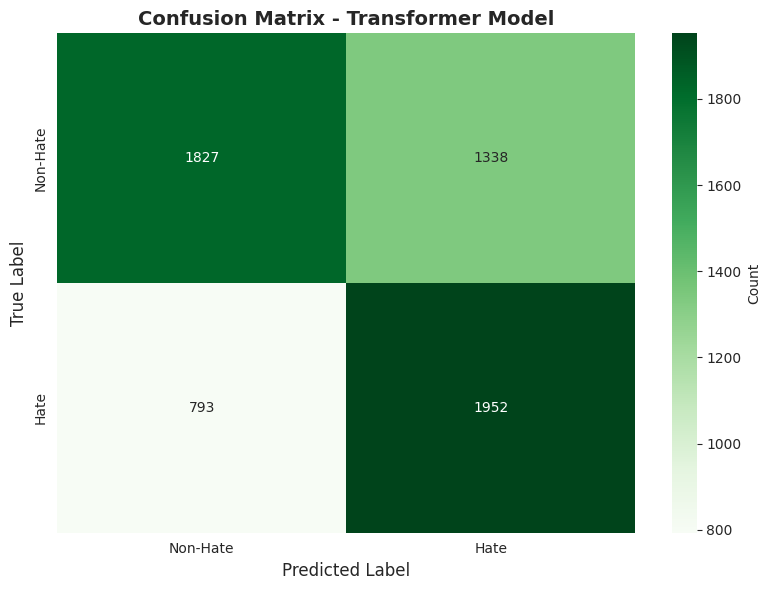

Confusion matrix saved


In [13]:
# Plot confusion matrix for transformer
plt.figure(figsize=(8, 6))
sns.heatmap(transformer_metrics['confusion_matrix'], annot=True, fmt='d', cmap='Greens',
            xticklabels=['Non-Hate', 'Hate'],
            yticklabels=['Non-Hate', 'Hate'],
            cbar_kws={'label': 'Count'})
plt.title('Confusion Matrix - Transformer Model', fontsize=14, fontweight='bold')
plt.ylabel('True Label', fontsize=12)
plt.xlabel('Predicted Label', fontsize=12)
plt.tight_layout()
plt.savefig('/content/confusion_matrix_transformer.png', dpi=100, bbox_inches='tight')
plt.show()
print("Confusion matrix saved")

In [14]:
# Compare models
print("\n" + "="*80)
print("MODEL COMPARISON SUMMARY")
print("="*80 + "\n")

comparison_data = {
    'Metric': ['Accuracy', 'Precision', 'Recall', 'F1 Score'],
    'Baseline (TF-IDF + LR)': [
        baseline_metrics['accuracy'],
        baseline_metrics['precision'],
        baseline_metrics['recall'],
        baseline_metrics['f1']
    ],
    'Transformer (XLM-RoBERTa)': [
        transformer_metrics['accuracy'],
        transformer_metrics['precision'],
        transformer_metrics['recall'],
        transformer_metrics['f1']
    ]
}

comparison_df = pd.DataFrame(comparison_data)
print(comparison_df.to_string(index=False))
print()

# Determine better model
f1_diff = transformer_metrics['f1'] - baseline_metrics['f1']
if f1_diff > 0:
    print(f"\nTRANSFORMER MODEL PERFORMS BETTER")
    print(f"  F1 improvement: {f1_diff:+.4f}")
else:
    print(f"\nBASELINE MODEL PERFORMS BETTER")
    print(f"  F1 difference: {f1_diff:+.4f}")


MODEL COMPARISON SUMMARY

   Metric  Baseline (TF-IDF + LR)  Transformer (XLM-RoBERTa)
 Accuracy                0.692386                   0.639425
Precision                0.665359                   0.593313
   Recall                0.679417                   0.711111
 F1 Score                0.672314                   0.646893


BASELINE MODEL PERFORMS BETTER
  F1 difference: -0.0254


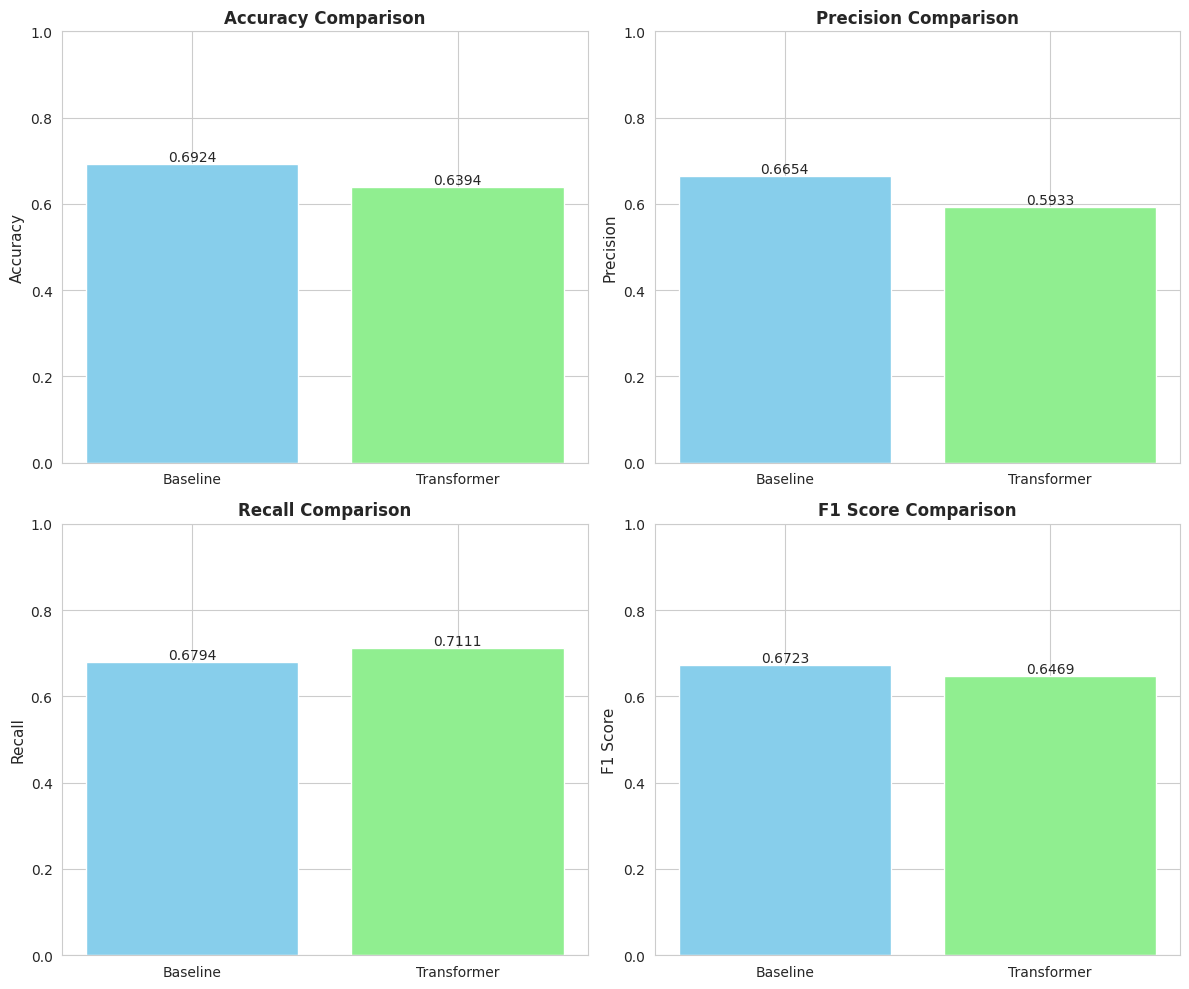

Comparison chart saved


In [15]:
# Visualize comparison
fig, axes = plt.subplots(2, 2, figsize=(12, 10))
metrics_list = ['accuracy', 'precision', 'recall', 'f1']
metric_labels = ['Accuracy', 'Precision', 'Recall', 'F1 Score']

for idx, (metric, label) in enumerate(zip(metrics_list, metric_labels)):
    ax = axes[idx // 2, idx % 2]
    values = [baseline_metrics[metric], transformer_metrics[metric]]
    bars = ax.bar(['Baseline', 'Transformer'], values, color=['skyblue', 'lightgreen'])
    ax.set_ylabel(label, fontsize=11)
    ax.set_ylim([0, 1])
    ax.set_title(f'{label} Comparison', fontsize=12, fontweight='bold')

    # Add value labels on bars
    for bar, val in zip(bars, values):
        height = bar.get_height()
        ax.text(bar.get_x() + bar.get_width()/2., height,
                f'{val:.4f}', ha='center', va='bottom', fontsize=10)

plt.tight_layout()
plt.savefig('/content/model_comparison.png', dpi=100, bbox_inches='tight')
plt.show()
print("Comparison chart saved")

In [16]:
print("\n" + "="*80)
print("SAVING MODELS AND RESULTS")
print("="*80 + "\n")

# Create output directory in Google Drive
output_dir = '/content/drive/MyDrive/hate_speech_results'
os.makedirs(output_dir, exist_ok=True)

# Save baseline model
print("Saving baseline model...")
baseline_dir = os.path.join(output_dir, 'baseline_model')
os.makedirs(baseline_dir, exist_ok=True)

with open(os.path.join(baseline_dir, 'model.pkl'), 'wb') as f:
    pickle.dump(baseline_model, f)
with open(os.path.join(baseline_dir, 'vectorizer.pkl'), 'wb') as f:
    pickle.dump(baseline_vectorizer, f)
print(f"  Baseline model saved to: {baseline_dir}")

# Save transformer model
print("Saving transformer model...")
transformer_dir = os.path.join(output_dir, 'transformer_model')
os.makedirs(transformer_dir, exist_ok=True)

model.save_pretrained(transformer_dir)
tokenizer.save_pretrained(transformer_dir)
print(f"  Transformer model saved to: {transformer_dir}")

# Save metrics to JSON
print("\nSaving metrics...")
metrics_report = {
    'baseline': {
        'accuracy': float(baseline_metrics['accuracy']),
        'precision': float(baseline_metrics['precision']),
        'recall': float(baseline_metrics['recall']),
        'f1': float(baseline_metrics['f1']),
        'roc_auc': float(baseline_metrics['roc_auc'])
    },
    'transformer': {
        'accuracy': float(transformer_metrics['accuracy']),
        'precision': float(transformer_metrics['precision']),
        'recall': float(transformer_metrics['recall']),
        'f1': float(transformer_metrics['f1'])
    },
    'timestamp': datetime.now().isoformat()
}

with open(os.path.join(output_dir, 'metrics.json'), 'w') as f:
    json.dump(metrics_report, f, indent=4)
print(f"  Metrics saved to: {os.path.join(output_dir, 'metrics.json')}")

# Generate text report
print("Generating text report...")
with open(os.path.join(output_dir, 'evaluation_report.txt'), 'w') as f:
    f.write("="*80 + "\n")
    f.write("HATE SPEECH DETECTION - MODEL EVALUATION REPORT\n")
    f.write("="*80 + "\n\n")
    f.write(f"Report generated: {datetime.now().strftime('%Y-%m-%d %H:%M:%S')}\n")
    f.write(f"Dataset size: {len(X_train)} training, {len(X_test)} test\n\n")

    f.write("BASELINE MODEL (TF-IDF + Logistic Regression)\n")
    f.write("-" * 80 + "\n")
    f.write(f"Accuracy:  {baseline_metrics['accuracy']:.4f}\n")
    f.write(f"Precision: {baseline_metrics['precision']:.4f}\n")
    f.write(f"Recall:    {baseline_metrics['recall']:.4f}\n")
    f.write(f"F1 Score:  {baseline_metrics['f1']:.4f}\n")
    f.write(f"ROC-AUC:   {baseline_metrics['roc_auc']:.4f}\n\n")

    f.write("TRANSFORMER MODEL (XLM-RoBERTa)\n")
    f.write("-" * 80 + "\n")
    f.write(f"Accuracy:  {transformer_metrics['accuracy']:.4f}\n")
    f.write(f"Precision: {transformer_metrics['precision']:.4f}\n")
    f.write(f"Recall:    {transformer_metrics['recall']:.4f}\n")
    f.write(f"F1 Score:  {transformer_metrics['f1']:.4f}\n\n")

    f.write("CLASSIFICATION REPORT (Transformer)\n")
    f.write("-" * 80 + "\n")
    f.write(classification_report(y_test, y_pred_transformer,
                                  target_names=['Non-Hate (0)', 'Hate (1)']))

print(f"  Report saved to: {os.path.join(output_dir, 'evaluation_report.txt')}")

# Copy PNG files
import shutil
for png_file in ['confusion_matrix_baseline.png', 'confusion_matrix_transformer.png', 'model_comparison.png']:
    if os.path.exists(f'/content/{png_file}'):
        shutil.copy(f'/content/{png_file}', os.path.join(output_dir, png_file))
        print(f"  {png_file} copied")

print(f"\nAll results saved to: {output_dir}")


SAVING MODELS AND RESULTS

Saving baseline model...
  Baseline model saved to: /content/drive/MyDrive/hate_speech_results/baseline_model
Saving transformer model...
  Transformer model saved to: /content/drive/MyDrive/hate_speech_results/transformer_model

Saving metrics...
  Metrics saved to: /content/drive/MyDrive/hate_speech_results/metrics.json
Generating text report...
  Report saved to: /content/drive/MyDrive/hate_speech_results/evaluation_report.txt
  confusion_matrix_baseline.png copied
  confusion_matrix_transformer.png copied
  model_comparison.png copied

All results saved to: /content/drive/MyDrive/hate_speech_results


In [17]:
# Test with sample texts
print("\n" + "="*80)
print("SAMPLE PREDICTIONS")
print("="*80 + "\n")

sample_texts = [
    "I love this movie",
    "You are stupid and should die",
    "Have a great day",
    "I absolutely hate you",
]

print("Baseline Model Predictions:")
print("-" * 80)
for text in sample_texts:
    clean = clean_text(text)
    tfidf = baseline_vectorizer.transform([clean])
    pred = baseline_model.predict(tfidf)[0]
    proba = baseline_model.predict_proba(tfidf)[0]
    label = "HATE" if pred == 1 else "NON-HATE"
    print(f"Text: {text}")
    print(f"  Prediction: {label} (confidence: {max(proba):.4f})\n")

print("\nTransformer Model Predictions:")
print("-" * 80)
for text in sample_texts:
    clean = clean_text(text)
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

    model.to(device)
    encoding = tokenizer(
    text,
    truncation=True,
    padding=True,
    max_length=128,
    return_tensors='pt')

    # Move tensors to same device as model
    encoding = {k: v.to(device) for k, v in encoding.items()}
    with torch.no_grad():
      output = model(**encoding)

    label = "HATE" if pred == 1 else "NON-HATE"
    print(f"Text: {text}")
    print(f"  Prediction: {label} (confidence: {max(proba).item():.4f})\n")


SAMPLE PREDICTIONS

Baseline Model Predictions:
--------------------------------------------------------------------------------
Text: I love this movie
  Prediction: HATE (confidence: 0.5616)

Text: You are stupid and should die
  Prediction: HATE (confidence: 0.9442)

Text: Have a great day
  Prediction: NON-HATE (confidence: 0.6067)

Text: I absolutely hate you
  Prediction: HATE (confidence: 0.6602)


Transformer Model Predictions:
--------------------------------------------------------------------------------
Text: I love this movie
  Prediction: HATE (confidence: 0.6602)

Text: You are stupid and should die
  Prediction: HATE (confidence: 0.6602)

Text: Have a great day
  Prediction: HATE (confidence: 0.6602)

Text: I absolutely hate you
  Prediction: HATE (confidence: 0.6602)



In [18]:
print("\n" + "="*80)
print("TRAINING COMPLETE - SUMMARY")
print("="*80 + "\n")

print("Results saved to Google Drive:")
print(f"  {output_dir}")
print()
print("Files generated:")
print(f"  - baseline_model/model.pkl")
print(f"  - baseline_model/vectorizer.pkl")
print(f"  - transformer_model/ (all model files)")
print(f"  - metrics.json")
print(f"  - evaluation_report.txt")
print(f"  - confusion_matrix_baseline.png")
print(f"  - confusion_matrix_transformer.png")
print(f"  - model_comparison.png")

print(f"\nBest Model: {'Transformer (XLM-RoBERTa)' if transformer_metrics['f1'] > baseline_metrics['f1'] else 'Baseline (TF-IDF + LR)'}")
print(f"Best F1 Score: {max(transformer_metrics['f1'], baseline_metrics['f1']):.4f}")
print(f"\nDataset Info:")
print(f"  - Total samples: {len(X_train) + len(X_test)}")
print(f"  - Training samples: {len(X_train)}")
print(f"  - Test samples: {len(X_test)}")
print(f"\n" + "="*80)


TRAINING COMPLETE - SUMMARY

Results saved to Google Drive:
  /content/drive/MyDrive/hate_speech_results

Files generated:
  - baseline_model/model.pkl
  - baseline_model/vectorizer.pkl
  - transformer_model/ (all model files)
  - metrics.json
  - evaluation_report.txt
  - confusion_matrix_baseline.png
  - confusion_matrix_transformer.png
  - model_comparison.png

Best Model: Baseline (TF-IDF + LR)
Best F1 Score: 0.6723

Dataset Info:
  - Total samples: 29550
  - Training samples: 23640
  - Test samples: 5910



In [19]:
import shutil
from google.colab import files

# 1. Zip the folder (replace 'folder_name' with your actual folder path)
shutil.make_archive('downloaded_folder', 'zip', '/content/drive/MyDrive/hate_speech_results')

# 2. Download the zipped file
files.download('downloaded_folder.zip')


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>